<img src='https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRIXJO_AnGlrzm96u_FS8TTJTZ7UyamK8iVNQ&usqp=CAU' width=1300 height=500 style="
  display: block; margin-left: auto; margin-right: auto; ">

# <center>UK Road Accidents Data
- The UK government amassed traffic data from 2000 and 2016, recording over **1.8 million** accidents in the process and making this one of the most comprehensive traffic data sets out there. It's a huge picture of a country undergoing change.

#### Import Libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly
import plotly.express as ex
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression


sns.set(style= 'whitegrid', color_codes=True)
# %matplotlib inline

In [27]:
# to measure linear / non-linear relationship B/W two columns
# pip install ppscore
# import ppscore as ppscore# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os

### 1. Data Import

In [28]:
df= pd.read_csv("/content/UK_Accident.csv")
# # final_df = pd.concat(sub_sets)
final_df= df
final_df.shape

/tmp/ipykernel_6357/427825363.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv("/content/UK_Accident.csv")


(115528, 33)

In [29]:
final_df.sample(4)

,Unnamed: 0,Accident_Index,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,...,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,LSOA_of_Accident_Location,Year
114027,114027,2.01E+12,624940.0,336670.0,1.341593,52.880397,36,3,1,1,...,No physical crossing within 50 meters,Darkeness: No street lighting,Fine without high winds,Dry,NaN,NaN,2.0,No,E01026766,2005.0
87609,87609,2.01E+12,383730.0,350130.0,-2.244163,53.048164,21,3,1,2,...,No physical crossing within 50 meters,Daylight: Street light present,Fine without high winds,Dry,NaN,NaN,1.0,Yes,E01029538,2005.0
91856,91856,200522EA31610,350840.0,239380.0,-2.718323,52.050579,22,3,2,1,...,No physical crossing within 50 meters,Daylight: Street light present,Fine without high winds,Dry,NaN,NaN,1.0,No,E01014074,2005.0
33344,33344,200504F027405,382270.0,431480.0,-2.270543,53.779342,4,2,1,1,...,No physical crossing within 50 meters,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1.0,Yes,E01024900,2005.0


## <u> Que-1:
- What are the number of casualties in each day of the week? Sort them in descending order.

In [30]:
print(final_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115528 entries, 0 to 115527
Data columns (total 33 columns):
 #   Column                                       Non-Null Count   Dtype  
---  ------                                       --------------   -----  
 0   Unnamed: 0                                   115528 non-null  int64  
 1   Accident_Index                               115528 non-null  object 
 2   Location_Easting_OSGR                        115497 non-null  float64
 3   Location_Northing_OSGR                       115528 non-null  float64
 4   Longitude                                    115497 non-null  float64
 5   Latitude                                     115528 non-null  float64
 6   Police_Force                                 115528 non-null  int64  
 7   Accident_Severity                            115528 non-null  int64  
 8   Number_of_Vehicles                           115528 non-null  int64  
 9   Number_of_Casualties                         115528 non-nul

In [31]:
final_df['Year'].unique()
final_df

,Unnamed: 0,Accident_Index,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,...,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,LSOA_of_Accident_Location,Year
0,0,200501BS00001,525680.0,178240.0,-0.191170,51.489096,1,2,1,1,...,Zebra crossing,Daylight: Street light present,Raining without high winds,Wet/Damp,NaN,NaN,1.0,Yes,E01002849,2005.0
1,1,200501BS00002,524170.0,181650.0,-0.211708,51.520075,1,3,1,1,...,Pedestrian phase at traffic signal junction,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1.0,Yes,E01002909,2005.0
2,2,200501BS00003,524520.0,182240.0,-0.206458,51.525301,1,3,2,1,...,No physical crossing within 50 meters,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1.0,Yes,E01002857,2005.0
3,3,200501BS00004,526900.0,177530.0,-0.173862,51.482442,1,3,1,1,...,No physical crossing within 50 meters,Daylight: Street light present,Fine without high winds,Dry,NaN,NaN,1.0,Yes,E01002840,2005.0
4,4,200501BS00005,528060.0,179040.0,-0.156618,51.495752,1,3,1,1,...,No physical crossing within 50 meters,Darkness: Street lighting unknown,Fine without high winds,Wet/Damp,NaN,NaN,1.0,Yes,E01002863,2005.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115523,115523,2010000000000.0,627960.0,330800.0,1.382289,52.826450,36,3,1,1,...,No physical crossing within 50 meters,Daylight: Street light present,Fine without high winds,Dry,NaN,NaN,1.0,Yes,E01026761,2005.0
115524,115524,2010000000000.0,643390.0,294040.0,1.583739,52.489893,36,2,1,1,...,No physical crossing within 50 meters,Darkeness: No street lighting,Fine without high winds,Dry,NaN,NaN,2.0,Yes,E01026943,2005.0
115525,115525,2010000000000.0,590570.0,340480.0,0.833763,52.927872,36,2,2,4,...,No physical crossing within 50 meters,Daylight: Street light present,Fine without high winds,Dry,NaN,NaN,2.0,Yes,E01026763,2005.0
115526,115526,2010000000000.0,620600.0,327720.0,1.271160,52.801868,36,3,2,4,...,No physical crossing within 50 meters,Darkeness: No street lighting,Fine without high winds,Dry,NaN,NaN,2.0,Yes,E01026501,2005.0


In [32]:
# dropping Junction_Detail as this column doesn't contribute anything
# final_df.drop(["Junction_Detail"],axis=1,inplace = True)

In [33]:
# As NULL values are less as compared to size of whole data
# So, Preprocessing the data and filling the null values with logically identified values from each feature.
final_df['Road_Surface_Conditions'].fillna(value = 'Normal', inplace = True)
final_df['Special_Conditions_at_Site'].fillna(value = 'None', inplace = True)
final_df['Carriageway_Hazards'].fillna(value = 'None', inplace = True)
final_df['Did_Police_Officer_Attend_Scene_of_Accident'].fillna(value = 'No', inplace = True)
final_df['Weather_Conditions'].fillna(value = 'Unknown', inplace = True)
final_df['Junction_Control'].fillna(value = 'None', inplace = True)
final_df['Location_Northing_OSGR'].fillna(value = 0, inplace = True)
final_df['Latitude'].fillna(value = 0, inplace = True)

/tmp/ipykernel_6357/321502268.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  final_df['Road_Surface_Conditions'].fillna(value = 'Normal', inplace = True)
/tmp/ipykernel_6357/321502268.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(v

In [34]:
data = {'Casualties_Count' : final_df['Number_of_Casualties'],
             'Day_of_Week' : final_df['Day_of_Week']}
accidents_per_week = pd.DataFrame(data)
accidents_per_week.groupby(by='Day_of_Week').sum().sort_values(by = 'Casualties_Count', ascending = False)

,Casualties_Count
Day_of_Week,
6,25594
4,23219
7,22825
5,22769
3,22546
2,21689
1,18895


In [35]:
cas_count= accidents_per_week.groupby(by='Day_of_Week').sum().sort_values(by = 'Casualties_Count', ascending = False)

In [36]:
# getting group-by size for sorting of color intensity according to Count values
size_gb= accidents_per_week.groupby(by='Day_of_Week').size()
dev_color= size_gb.argsort().argsort() # argsort for index wise sorting
pal= sns.color_palette('Reds', len(dev_color)) # choose color palette accordingly

/tmp/ipykernel_6357/2686937464.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=accidents_per_week.Day_of_Week,
/tmp/ipykernel_6357/2686937464.py:1: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.countplot(x=accidents_per_week.Day_of_Week,


<Axes: xlabel='Day_of_Week', ylabel='count'>

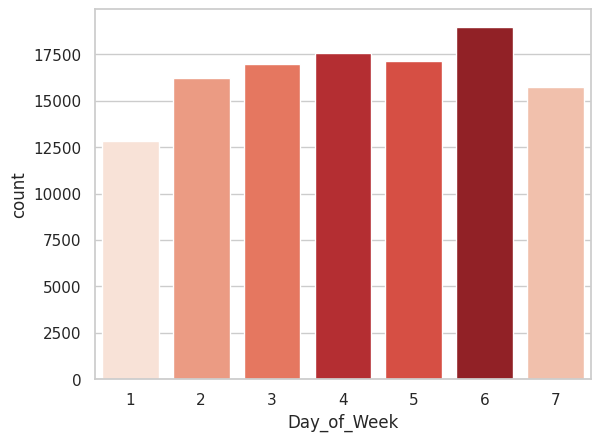

In [37]:
sns.countplot(x=accidents_per_week.Day_of_Week,
              data=accidents_per_week,
              palette=np.array(pal[::])[dev_color])
# 6th day of the week has seen more number of accidents

## <u> Que-3:
- On each day of the week, what is the maximum and minimum speed limit on the roads the accidents happened?

In [38]:
accidents_per_week['Speed_Limit'] = final_df.Speed_limit
accidents_per_week.sample(4)

,Casualties_Count,Day_of_Week,Speed_Limit
61208,1,5,60
113898,2,4,30
83335,1,1,30
40261,4,2,40


- For this Question we'll make use of SQL-Language
- To use SQL use with Pandas there's Package <u> pandasql

In [25]:

!pip install pandasql
import pandasql as ps

  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=541a1408f1ffd81214e9c3258b813a8859168d7cf7553f18edd4f9d730357349
  Stored in directory: /root/.cache/pip/wheels/15/a1/e7/6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql


In [39]:
chunks = []
for val in range(1,8) : # Since there are 7 days, we're using the loop from 1 to 8.
    qurery1 = """select accidents_per_week.Day_of_Week, sum(accidents_per_week.Casualties_Count) Casualties_Count,
            max(accidents_per_week.Speed_Limit) Max_Speed ,min(accidents_per_week.Speed_Limit) Min_Speed
            from accidents_per_week where accidents_per_week.Casualties_Count > 0 and accidents_per_week.Day_of_Week= """+str(val)
    chunks.append(ps.sqldf(qurery1, locals())) # parameters (Query, db_url) and returns DataFrame

speed_limit_accident_data = pd.concat(chunks, ignore_index=True) # concatination of chunks

In [40]:
speed_limit_accident_data

,Day_of_Week,Casualties_Count,Max_Speed,Min_Speed
0,1,18895,70,20
1,2,21689,70,20
2,3,22546,70,20
3,4,23219,70,20
4,5,22769,70,20
5,6,25594,70,20
6,7,22825,70,10


/tmp/ipykernel_6357/3032313388.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Day_of_Week', y = 'Min_Speed' , data=speed_limit_accident_data, palette='YlGnBu_r')


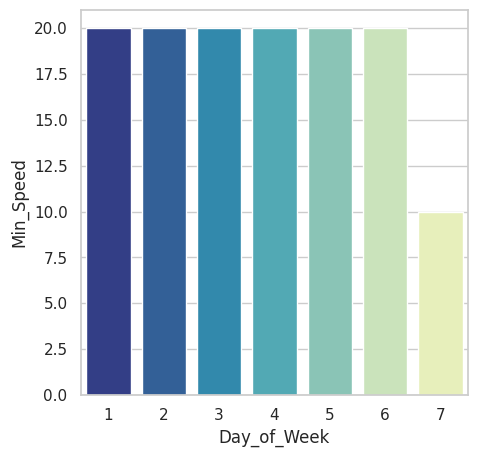

/tmp/ipykernel_6357/3032313388.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Day_of_Week', y = 'Max_Speed' , data=speed_limit_accident_data, palette='YlGnBu')


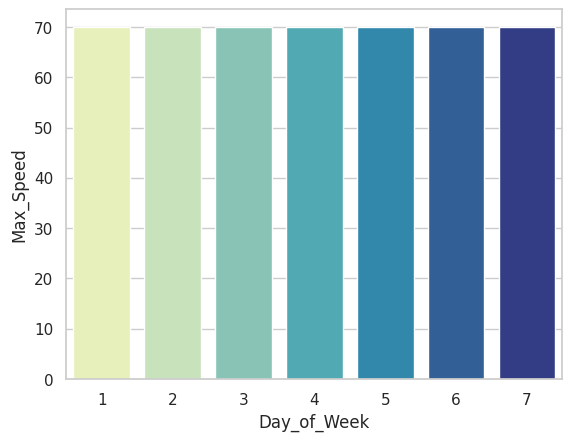

In [41]:
val = ["Max-Speed","Min_Speed"]
plt.figure(figsize=(5,5))
sns.barplot(x='Day_of_Week', y = 'Min_Speed' , data=speed_limit_accident_data, palette='YlGnBu_r')
plt.show()
sns.barplot(x='Day_of_Week', y = 'Max_Speed' , data=speed_limit_accident_data, palette='YlGnBu')
plt.show()

## <u> Que-4:
- What is the importance of Light and Weather conditions in predicting accident severity?
- What does your intuition say and what does the data portray?

In [42]:
accident_severity_data = {'Light_Conditions' : final_df.Light_Conditions,
                          'Weather_Conditions' : final_df.Weather_Conditions,
                          'Accident_Severity' : final_df.Accident_Severity}
accident_severity_df = pd.DataFrame(accident_severity_data)
accident_severity_df.sample(4)

,Light_Conditions,Weather_Conditions,Accident_Severity
70390,Daylight: Street light present,Fine without high winds,3
37425,Daylight: Street light present,Fine with high winds,3
61006,Darkness: Street lights present and lit,Raining without high winds,3
70318,Daylight: Street light present,Fine without high winds,3


In [43]:
print(accident_severity_df.describe(),'\n')
print(accident_severity_df.info())

       Accident_Severity
count      115528.000000
mean            2.846600
std             0.395464
min             1.000000
25%             3.000000
50%             3.000000
75%             3.000000
max             3.000000 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115528 entries, 0 to 115527
Data columns (total 3 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   Light_Conditions    115528 non-null  object
 1   Weather_Conditions  115528 non-null  object
 2   Accident_Severity   115528 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 2.6+ MB
None


In [44]:
# Converting Object data-type into Category datatype
for object_feature in accident_severity_df.dtypes[accident_severity_df.dtypes == 'object'].index :
     accident_severity_df[object_feature] = accident_severity_df[object_feature].astype('category')

In [45]:
accident_severity_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115528 entries, 0 to 115527
Data columns (total 3 columns):
 #   Column              Non-Null Count   Dtype   
---  ------              --------------   -----   
 0   Light_Conditions    115528 non-null  category
 1   Weather_Conditions  115528 non-null  category
 2   Accident_Severity   115528 non-null  int64   
dtypes: category(2), int64(1)
memory usage: 1.1 MB


In [46]:
# One Hot Encoding the categorical columns
accident_severity_df = pd.get_dummies(data=accident_severity_df, columns=['Light_Conditions', 'Weather_Conditions'])

In [47]:
accident_severity_df.sample(2)

,Accident_Severity,Light_Conditions_Darkeness: No street lighting,Light_Conditions_Darkness: Street lighting unknown,Light_Conditions_Darkness: Street lights present and lit,Light_Conditions_Darkness: Street lights present but unlit,Light_Conditions_Daylight: Street light present,Weather_Conditions_Fine with high winds,Weather_Conditions_Fine without high winds,Weather_Conditions_Fog or mist,Weather_Conditions_Other,Weather_Conditions_Raining with high winds,Weather_Conditions_Raining without high winds,Weather_Conditions_Snowing with high winds,Weather_Conditions_Snowing without high winds,Weather_Conditions_Unknown
82944,3,False,False,False,False,True,False,True,False,False,False,False,False,False,False
106669,3,False,False,False,False,True,False,False,False,True,False,False,False,False,False


In [48]:
# Correlation between 'Accident_Severity' and rest of variables
accident_severity = accident_severity_df.corr().loc['Accident_Severity':]
accident_severity = pd.DataFrame(accident_severity)

In [49]:
# np.hstack(np.split(accident_severity, 1))
accident_severity

,Accident_Severity,Light_Conditions_Darkeness: No street lighting,Light_Conditions_Darkness: Street lighting unknown,Light_Conditions_Darkness: Street lights present and lit,Light_Conditions_Darkness: Street lights present but unlit,Light_Conditions_Daylight: Street light present,Weather_Conditions_Fine with high winds,Weather_Conditions_Fine without high winds,Weather_Conditions_Fog or mist,Weather_Conditions_Other,Weather_Conditions_Raining with high winds,Weather_Conditions_Raining without high winds,Weather_Conditions_Snowing with high winds,Weather_Conditions_Snowing without high winds,Weather_Conditions_Unknown
Accident_Severity,1.000000,-0.082492,-0.003737,-0.028692,-0.007203,0.064975,-0.007650,-0.025759,-0.001035,0.015589,-0.002595,0.019653,-0.003996,0.010812,0.013938
Light_Conditions_Darkeness: No street lighting,-0.082492,1.000000,-0.016028,-0.112225,-0.012887,-0.332914,0.032720,-0.058443,0.041760,0.026009,0.043020,0.019617,0.023883,0.028898,-0.007129
Light_Conditions_Darkness: Street lighting unknown,-0.003737,-0.016028,1.000000,-0.042070,-0.004831,-0.124800,0.000694,-0.060785,0.002848,0.009887,0.001365,-0.005415,0.000890,-0.001928,0.178191
Light_Conditions_Darkness: Street lights present and lit,-0.028692,-0.112225,-0.042070,1.000000,-0.033825,-0.873817,0.014336,-0.093558,0.014379,0.044302,0.028267,0.080490,-0.000135,0.006321,-0.008827
Light_Conditions_Darkness: Street lights present but unlit,-0.007203,-0.012887,-0.004831,-0.033825,1.000000,-0.100342,0.005882,-0.017138,0.001804,0.013532,0.003319,0.007158,0.006473,0.008470,0.003038
Light_Conditions_Daylight: Street light present,0.064975,-0.332914,-0.124800,-0.873817,-0.100342,1.000000,-0.028820,0.126193,-0.032665,-0.056521,-0.046168,-0.084029,-0.011490,-0.019540,-0.019643
Weather_Conditions_Fine with high winds,-0.007650,0.032720,0.000694,0.014336,0.005882,-0.028820,1.000000,-0.229766,-0.007616,-0.016540,-0.010248,-0.039537,-0.003623,-0.009934,-0.015008
Weather_Conditions_Fine without high winds,-0.025759,-0.058443,-0.060785,-0.093558,-0.017138,0.126193,-0.229766,1.000000,-0.143266,-0.311154,-0.192795,-0.743769,-0.068150,-0.186884,-0.282337
Weather_Conditions_Fog or mist,-0.001035,0.041760,0.002848,0.014379,0.001804,-0.032665,-0.007616,-0.143266,1.000000,-0.010313,-0.006390,-0.024652,-0.002259,-0.006194,-0.009358
Weather_Conditions_Other,0.015589,0.026009,0.009887,0.044302,0.013532,-0.056521,-0.016540,-0.311154,-0.010313,1.000000,-0.013879,-0.053541,-0.004906,-0.013453,-0.020324


<Axes: >

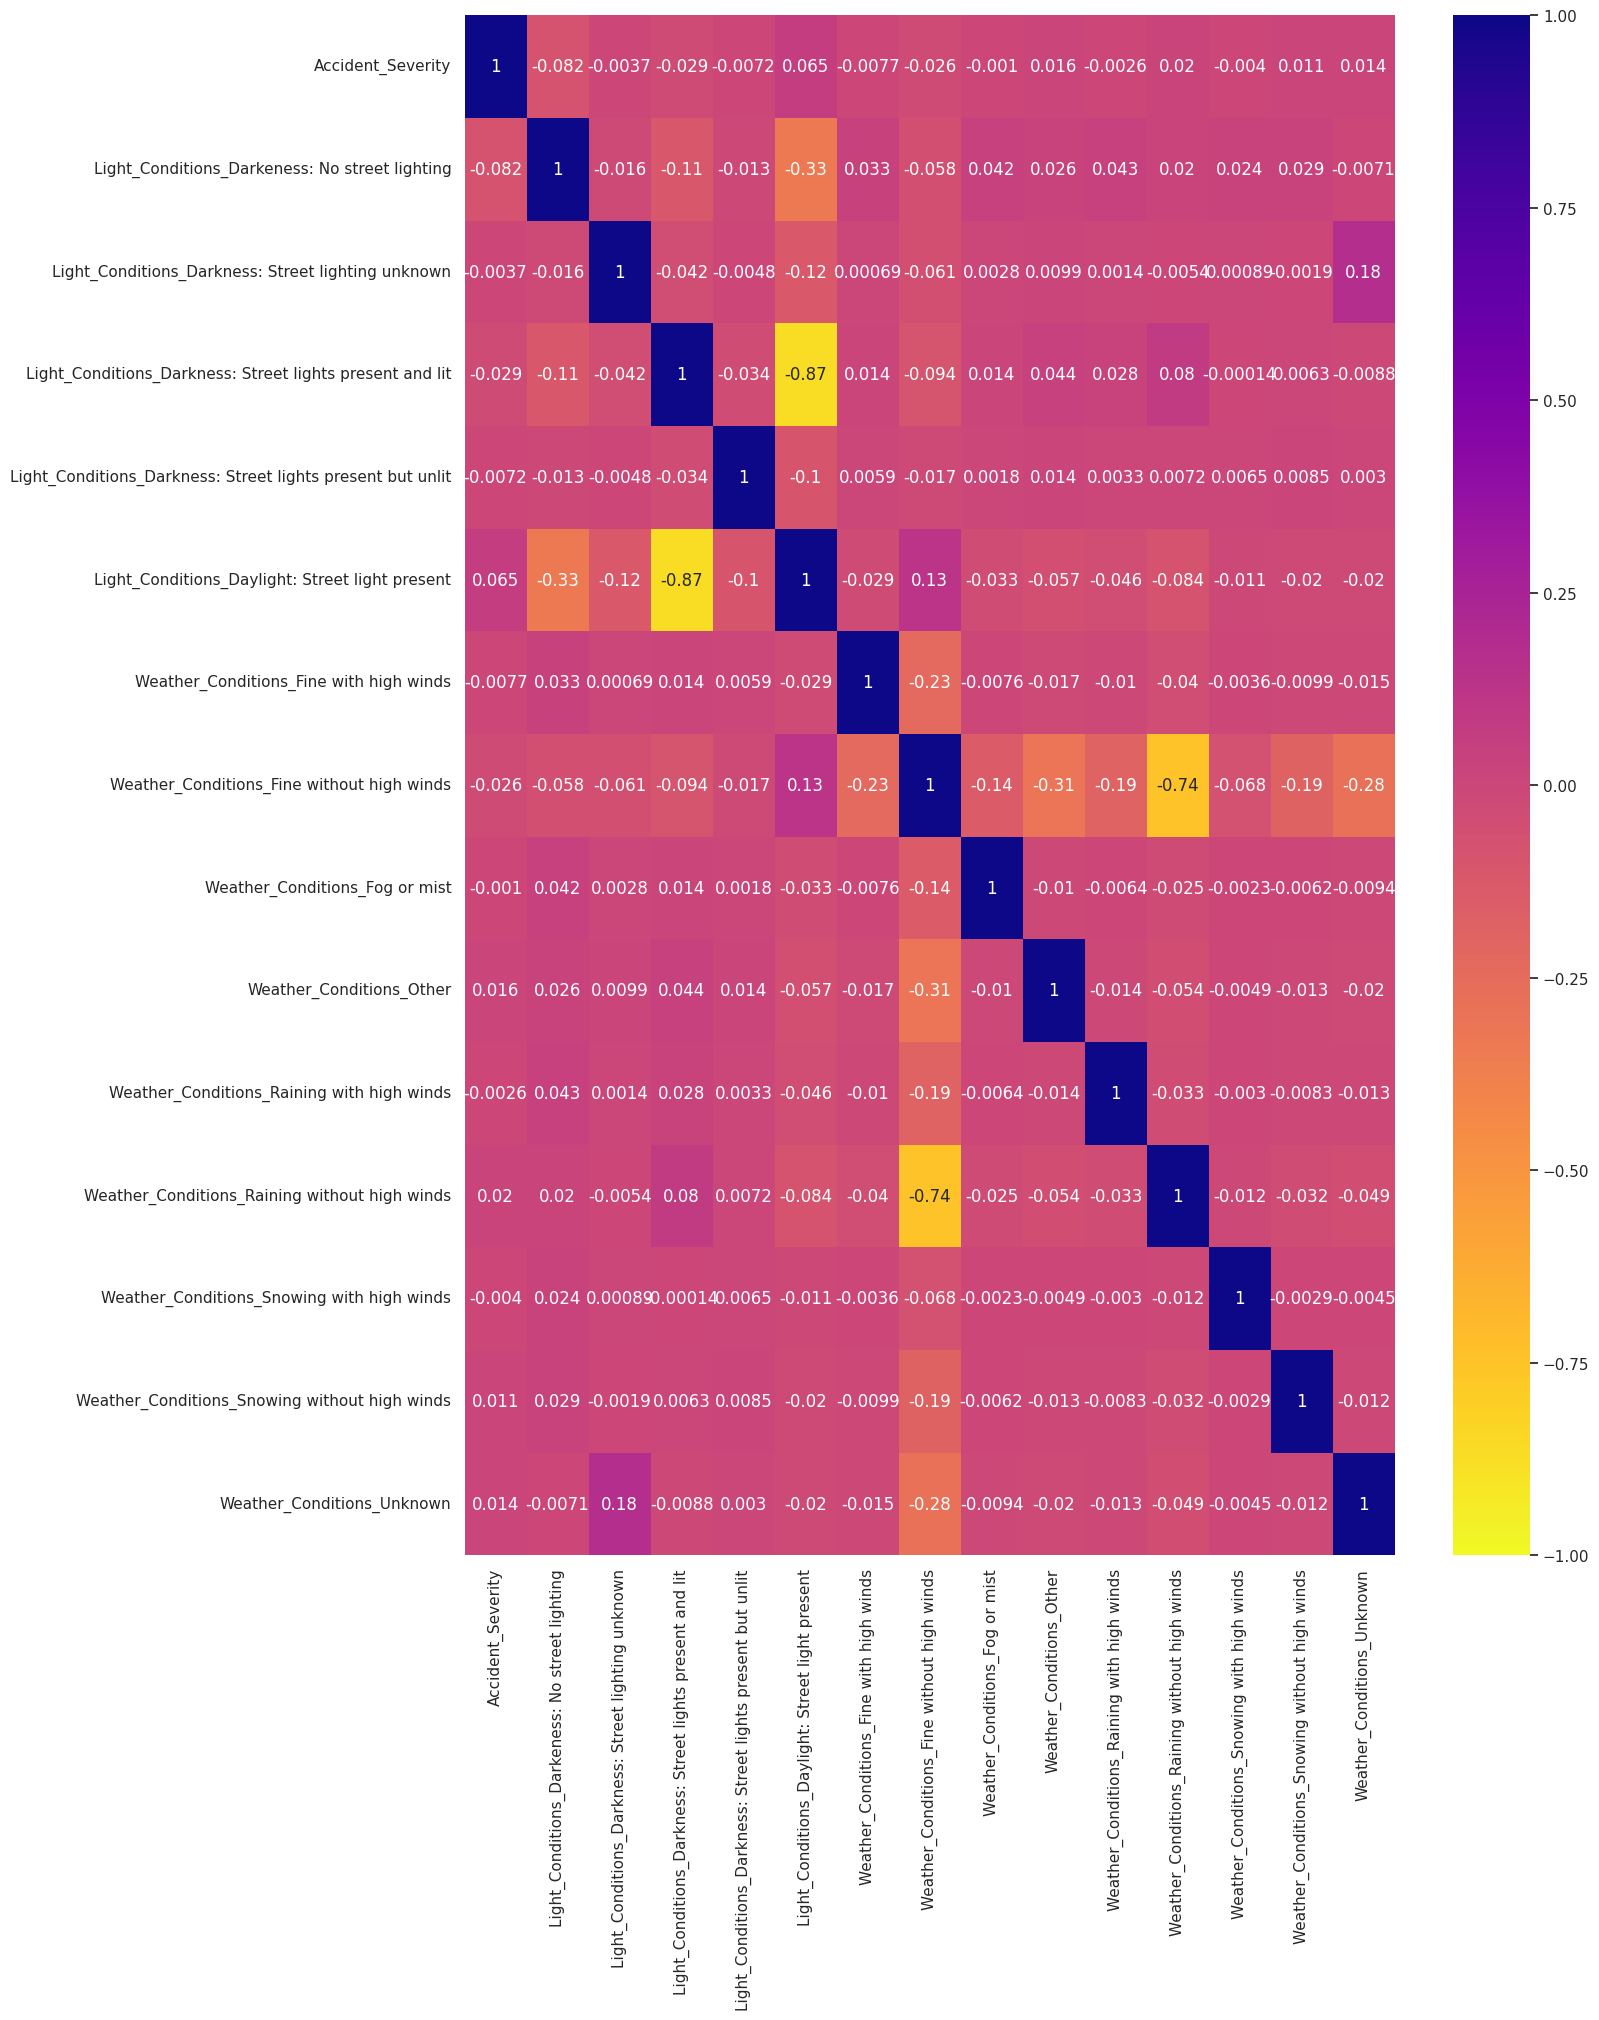

In [50]:
plt.figure(figsize=(15,20))
sns.heatmap(accident_severity, vmin=-1, cmap='plasma_r', annot = True)

### <u>Intuition (Summary):
- As per our intuition, we can say that the number of accidents will be more when the light and weather conditions are at worse. Like when there is no there light present at night, the number of accidents could be more. Similarly, in bad weather conditions like too much winds, rainfall or snowing could lead to more number of accidents.

- From Data: From the above correlation matrix of the data, we can observe that both Light_conditions and Weather_Conditions doesn't have much effect on Accident_severity as they are almost close to 0. Light_conditions with Street Light present is more impactful compared to Weather_Conditions.

- So the interpretation could be like when Street Light is present compared Daytime, the number of accidents being caused and their severity are much higher.

## <u>Que-5:
- To predict the severity of the accidents which columns are unnecessary as logically and should be dropped before implementing a any prediction (regression) model.

In [51]:
# From the above correlation, we have seen that Light_Conditions and Weather_Conditions are not much impactful,
# so we can drop them
accident_severity_df =final_df.copy()
accident_severity_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115528 entries, 0 to 115527
Data columns (total 33 columns):
 #   Column                                       Non-Null Count   Dtype  
---  ------                                       --------------   -----  
 0   Unnamed: 0                                   115528 non-null  int64  
 1   Accident_Index                               115528 non-null  object 
 2   Location_Easting_OSGR                        115497 non-null  float64
 3   Location_Northing_OSGR                       115528 non-null  float64
 4   Longitude                                    115497 non-null  float64
 5   Latitude                                     115528 non-null  float64
 6   Police_Force                                 115528 non-null  int64  
 7   Accident_Severity                            115528 non-null  int64  
 8   Number_of_Vehicles                           115528 non-null  int64  
 9   Number_of_Casualties                         115528 non-nul

In [52]:
accident_severity_df['Pedestrian_Crossing-Human_Control'].value_counts()
accident_severity_df['Pedestrian_Crossing-Physical_Facilities'].value_counts()
accident_severity_df['Light_Conditions'].value_counts()
accident_severity_df['Special_Conditions_at_Site'].value_counts()
accident_severity_df['Carriageway_Hazards'].value_counts()
accident_severity_df['Junction_Control'].value_counts()

,count
Junction_Control,
Giveway or uncontrolled,57996
None,42406
Automatic traffic signal,14101
Stop Sign,837
Authorised person,188


#### From above Numbers,
- Pedestrian_Crossing can be dropped as almost 90% of the data is None
- Pedestrian_Crossing-Physical_Facilities can be dropped as almost 80% of the data is None
- Light_Conditions can be dropped as earlier we have seen Light_Conditions & Weather_Conditions are not much impactful
- Special_Conditions_at_Site can be dropped as 90% data is None
- Carriageway_Hazards can be dropped as 90% data is None
- Did_Police_Officer_Attend_Scene_of_Accident can be dropped as Police comes after the accident has occured and it doesn't logically impact the severity of the accident
- Carriageway_Hazards can be dropped as 90% data is None
- We can also drop Accident_Index as it only keeps the count of the accidents
- We can also drop Date, Time of Accidents as logically they don't impact the Severity of Accidents

In [53]:
drop_cols= ['Pedestrian_Crossing-Human_Control','Pedestrian_Crossing-Physical_Facilities','Light_Conditions'
           ,'Special_Conditions_at_Site','Carriageway_Hazards','Carriageway_Hazards','Junction_Control'
           ,'Did_Police_Officer_Attend_Scene_of_Accident']

/tmp/ipykernel_6357/1962147851.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = 'Road_Type', y = 'Accident_Severity', data = accident_severity_df, palette='rocket')


<Axes: xlabel='Road_Type', ylabel='Accident_Severity'>

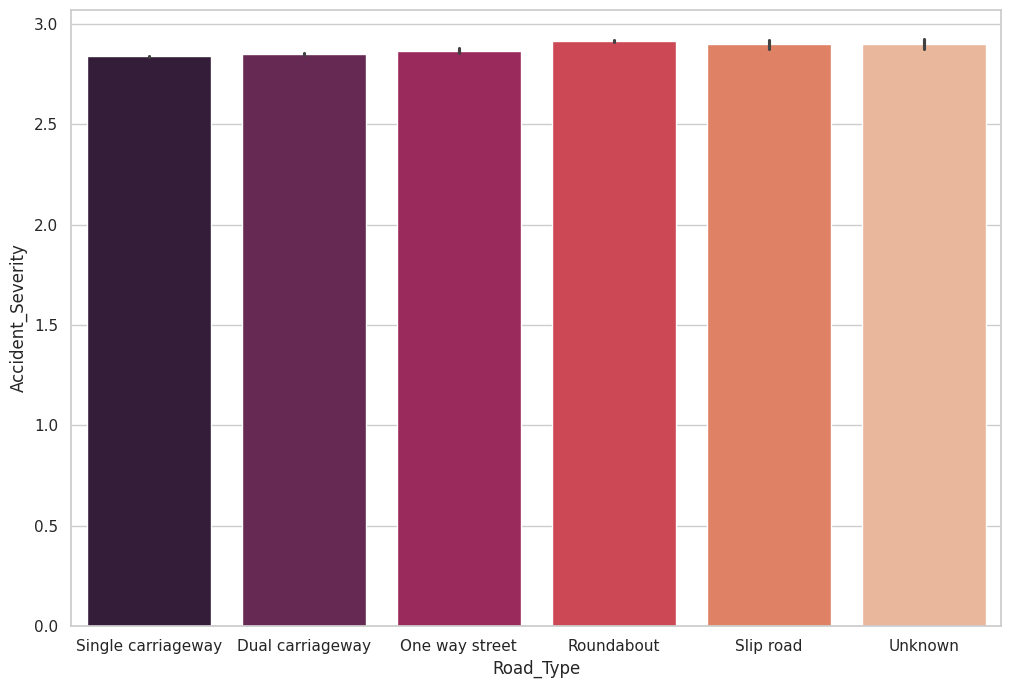

In [54]:
plt.figure(figsize=(12,8))
sns.barplot(x = 'Road_Type', y = 'Accident_Severity', data = accident_severity_df, palette='rocket')

/tmp/ipykernel_6357/3156746298.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = 'Road_Surface_Conditions', y = 'Accident_Severity', data = accident_severity_df, palette='rocket_r')


<Axes: xlabel='Road_Surface_Conditions', ylabel='Accident_Severity'>

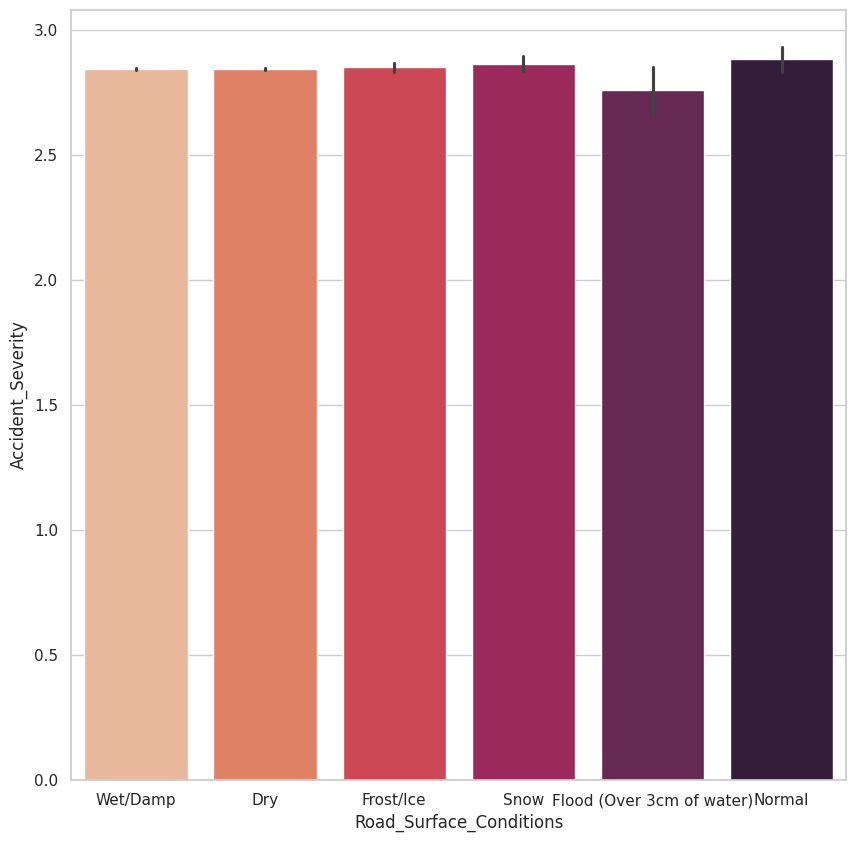

In [55]:
plt.figure(figsize=(10,10))
sns.barplot(x = 'Road_Surface_Conditions', y = 'Accident_Severity', data = accident_severity_df, palette='rocket_r')

In [56]:
# final_df.to_csv('UK_Accident.csv')

In [57]:
for feature in accident_severity_df.dtypes[accident_severity_df.dtypes == 'object'].index :
    accident_severity_df.drop(columns = feature, inplace = True)

In [58]:
accident_severity_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115528 entries, 0 to 115527
Data columns (total 18 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Unnamed: 0                  115528 non-null  int64  
 1   Location_Easting_OSGR       115497 non-null  float64
 2   Location_Northing_OSGR      115528 non-null  float64
 3   Longitude                   115497 non-null  float64
 4   Latitude                    115528 non-null  float64
 5   Police_Force                115528 non-null  int64  
 6   Accident_Severity           115528 non-null  int64  
 7   Number_of_Vehicles          115528 non-null  int64  
 8   Number_of_Casualties        115528 non-null  int64  
 9   Day_of_Week                 115528 non-null  int64  
 10  Local_Authority_(District)  115528 non-null  int64  
 11  1st_Road_Class              115528 non-null  int64  
 12  1st_Road_Number             115528 non-null  int64  
 13  Speed_limit   

In [59]:
corr_matrix = accident_severity_df.corr()
corr_matrix

,Unnamed: 0,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Day_of_Week,Local_Authority_(District),1st_Road_Class,1st_Road_Number,Speed_limit,2nd_Road_Class,2nd_Road_Number,Urban_or_Rural_Area,Year
Unnamed: 0,1.000000,-0.143910,0.281128,-0.127060,0.215783,0.935326,-0.031564,0.030232,0.077525,0.001517,0.955499,0.056568,0.121955,0.294697,-0.087303,0.095071,0.329433,NaN
Location_Easting_OSGR,-0.143910,1.000000,-0.613259,0.999713,-0.616931,0.034319,0.001893,-0.025206,-0.085602,-0.004632,-0.080627,-0.061273,-0.153769,-0.085643,-0.010726,-0.070378,-0.107193,NaN
Location_Northing_OSGR,0.281128,-0.613259,1.000000,-0.599940,0.787936,0.118287,-0.020300,0.011982,0.101722,0.006094,0.210837,0.084381,0.082045,0.182598,-0.020984,0.035786,0.235880,NaN
Longitude,-0.127060,0.999713,-0.599940,1.000000,-0.603622,0.048833,0.001241,-0.024958,-0.083869,-0.004599,-0.064725,-0.059257,-0.152904,-0.080493,-0.011839,-0.069610,-0.101214,NaN
Latitude,0.215783,-0.616931,0.787936,-0.603622,1.000000,0.094145,-0.015900,0.009243,0.076835,0.005437,0.163331,0.063854,0.061449,0.133860,-0.010375,0.030219,0.139564,NaN
Police_Force,0.935326,0.034319,0.118287,0.048833,0.094145,1.000000,-0.029387,0.019931,0.054134,-0.000652,0.978700,0.037882,0.104644,0.267639,-0.088392,0.094783,0.303153,NaN
Accident_Severity,-0.031564,0.001893,-0.020300,0.001241,-0.015900,-0.029387,1.000000,0.085990,-0.103194,0.001084,-0.028135,0.010362,-0.001377,-0.091895,0.078529,0.030897,-0.092635,NaN
Number_of_Vehicles,0.030232,-0.025206,0.011982,-0.024958,0.009243,0.019931,0.085990,1.000000,0.224674,-0.009047,0.023341,-0.132188,0.001844,0.096627,0.062443,0.021479,0.052816,NaN
Number_of_Casualties,0.077525,-0.085602,0.101722,-0.083869,0.076835,0.054134,-0.103194,0.224674,1.000000,0.001393,0.065757,-0.075428,0.019567,0.151832,-0.027550,0.012039,0.130466,NaN
Day_of_Week,0.001517,-0.004632,0.006094,-0.004599,0.005437,-0.000652,0.001084,-0.009047,0.001393,1.000000,-0.000232,0.005620,0.007682,-0.017846,0.006869,0.006009,-0.017964,NaN


<Axes: >

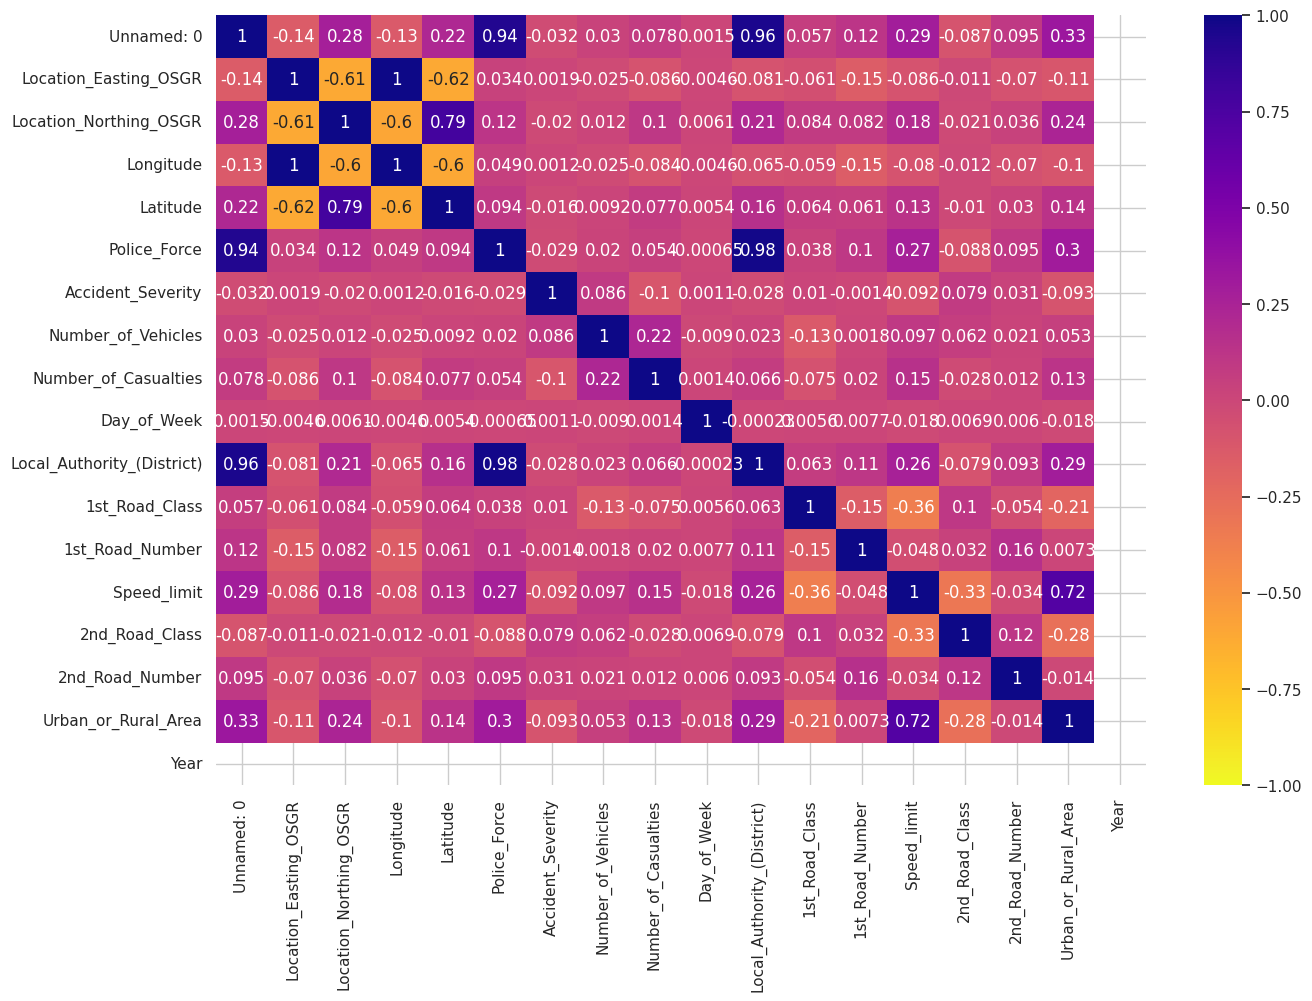

In [60]:
plt.figure(figsize=(15,10))
sns.heatmap(corr_matrix, annot=True, vmin=-1, cmap='plasma_r')

<Axes: >

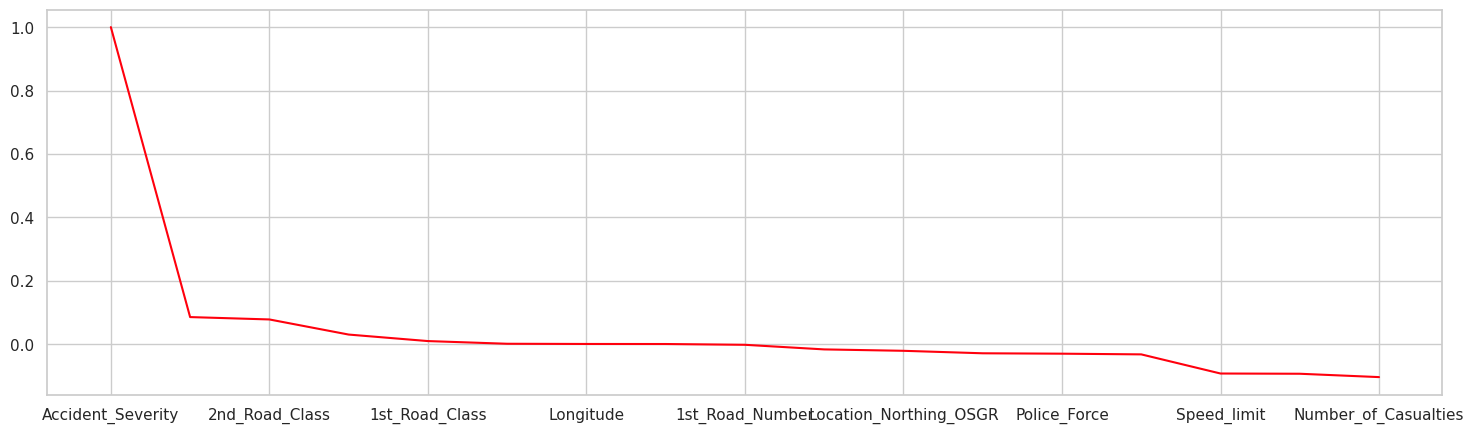

In [61]:
plt.figure(figsize=(18,5))
corr_matrix['Accident_Severity'].sort_values(ascending=False).plot(color='#ff000d')

In [62]:
final_accident_severity_df = accident_severity_df.copy()
final_accident_severity_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115528 entries, 0 to 115527
Data columns (total 18 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Unnamed: 0                  115528 non-null  int64  
 1   Location_Easting_OSGR       115497 non-null  float64
 2   Location_Northing_OSGR      115528 non-null  float64
 3   Longitude                   115497 non-null  float64
 4   Latitude                    115528 non-null  float64
 5   Police_Force                115528 non-null  int64  
 6   Accident_Severity           115528 non-null  int64  
 7   Number_of_Vehicles          115528 non-null  int64  
 8   Number_of_Casualties        115528 non-null  int64  
 9   Day_of_Week                 115528 non-null  int64  
 10  Local_Authority_(District)  115528 non-null  int64  
 11  1st_Road_Class              115528 non-null  int64  
 12  1st_Road_Number             115528 non-null  int64  
 13  Speed_limit   

In [63]:
# deleting the columns with correlation < 0.02 and >-0.02 as they are not much impactful compared to others
for feature in accident_severity_df.dtypes[accident_severity_df.dtypes != 'object'].index :
    if(corr_matrix['Accident_Severity'][feature] < 0.02 and  corr_matrix['Accident_Severity'][feature] > -0.02) :
        final_accident_severity_df.drop(columns = feature, inplace = True)

# Inversely proportional columns as well as they can impact the Accident_severity (> -0.02)

In [64]:
# Impactful columns for Accident_Severity are as follows
final_accident_severity_df.sample(4)

,Unnamed: 0,Location_Northing_OSGR,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Local_Authority_(District),Speed_limit,2nd_Road_Class,2nd_Road_Number,Urban_or_Rural_Area,Year
102554,102554,339810.0,31,3,2,1,347,30,-1,0,2.0,2005.0
18822,18822,177090.0,1,2,1,1,10,30,-1,0,1.0,2005.0
110106,110106,277800.0,34,3,4,1,382,70,-1,0,2.0,2005.0
61643,61643,435580.0,13,3,2,2,204,30,6,0,1.0,2005.0


## <u>Additive Work:
- I've used Logistic Regression Model using scikit learn with cross validation = 5, where you predict the severity of the accident (Accident_Severity).
- here, i've not optimized hyperparameter but figured out what features will be best to use.

In [65]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

In [66]:
check = final_accident_severity_df.copy()
severity = check['Accident_Severity']
severity = pd.DataFrame(severity, columns = ['Accident_Severity'])

In [67]:
severity.sample(3)

,Accident_Severity
100807,3
51540,2
5737,2


<u>**Multiclass classification**</u> with logistic regression can be done either through the one-vs-rest scheme in which for each class a binary classification problem of data belonging or not to that class is done, or changing the loss function to cross- entropy loss.

In the multiclass case, the training algorithm uses the one-vs-rest (OvR) scheme if the ‘multi_class’ option is set to ‘ovr’ and uses the cross-entropy loss if the ‘multi_class’ option is set to ‘multinomial’. (Currently, the ‘multinomial’ option is supported only by the ‘lbfgs’, ‘sag’ and ‘newton-cg’ solvers.) By default, multi_class is set to ’ovr’.

In [68]:
model = LogisticRegression(solver = 'lbfgs', max_iter = 100)
score = cross_val_score(model, check, severity, cv = 5)
score.mean()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent 

np.float64(nan)

### I Hope You Liked the Notebook and Learned something new from the Notebook